In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('sales_records.csv')
df.head()

,id,product,quantity,price,category,date
0,1,Wireless Mouse,25,29.99,Electronics,2025-01-15
1,2,USB-C Hub,12,45.50,Electronics,2025-01-16
2,3,Desk Lamp,8,39.99,Lighting,2025-01-17
3,4,Notebook Set,50,12.49,Stationery,2025-01-18
4,5,Bluetooth Speaker,15,79.99,Electronics,2025-01-19


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10 non-null     int64  
 1   product   10 non-null     str    
 2   quantity  10 non-null     int64  
 3   price     10 non-null     float64
 4   category  10 non-null     str    
 5   date      10 non-null     str    
dtypes: float64(1), int64(2), str(3)
memory usage: 612.0 bytes


,id,quantity,price
count,10.00000,10.000000,10.000000
mean,5.50000,21.300000,60.693000
std,3.02765,15.018877,71.217311
min,1.00000,3.000000,12.490000
25%,3.25000,10.500000,20.740000
50%,5.50000,17.500000,34.990000
75%,7.75000,28.750000,71.367500
max,10.00000,50.000000,249.000000


In [4]:
df['total_sale'] = df['quantity'] * df['price']
total_revenue = df['total_sale'].sum()
print(f'Total Revenue: ${total_revenue:.2f}')

top_products = df.nlargest(3, 'total_sale')[['product', 'total_sale']]
print('\nTop 3 Products by Revenue:')
print(top_products.to_string(index=False))

Total Revenue: $6776.42

Top 3 Products by Revenue:
            product  total_sale
  Bluetooth Speaker     1199.85
Mechanical Keyboard      899.90
     Wireless Mouse      749.75


In [5]:
cat_summary = df.groupby('category').agg(
    total_revenue=('total_sale', 'sum'),
    avg_price=('price', 'mean'),
    total_qty=('quantity', 'sum')
).round(2)
cat_summary

,total_revenue,avg_price,total_qty
category,,,
Electronics,3395.50,61.37,62
Furniture,747.00,249.00,3
Lighting,889.62,29.49,38
Sports,1119.80,20.49,60
Stationery,624.50,12.49,50


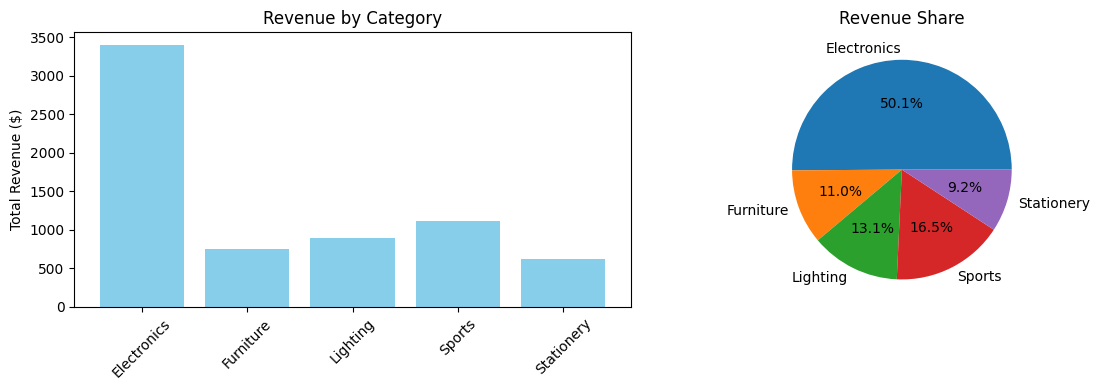

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cat_summary.index, cat_summary['total_revenue'], color='skyblue')
axes[0].set_title('Revenue by Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(cat_summary['total_revenue'], labels=cat_summary.index, autopct='%1.1f%%')
axes[1].set_title('Revenue Share')

plt.tight_layout()
plt.show()